#### Why Multivariate Linear Regression

Linear regression and Polynimial regression are best suite when there is only single feature variable as X and single target variable as y.

But what if we have many features as X1, X2, .... Xn and single target variable as y.

Mathametically, We should sum all the X values (X1, X2, .... Xn) and call them as X. This X can now be used as a single feature to map with a target. The machine would check the relations between these X1, X2, .... Xn to form a single X as feature

#### Import all libraries and dataframe

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

#### Import Data and Do Some Analysis if needed

In [3]:
dataset = pd.read_csv("../../Data/homeprice.csv")
dataset.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,05/02/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,05/02/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,05/02/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,05/02/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,05/02/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


#### Clean up the data
I am applying some data analysing techniques to this data as it is not completely suitable for machine learning, Machine learning only accept cleaned dataset with minimium but meaningful columns.

Therefore I would ignore some data columns and fill out the NA or NAN values.

In [4]:
dataset = dataset[["view","bedrooms","bathrooms","floors","condition","price"]]

In [5]:
dataset.head()

,view,bedrooms,bathrooms,floors,condition,price
0,0,3,1.50,1.5,3,313000.0
1,4,5,2.50,2.0,5,2384000.0
2,0,3,2.00,1.0,4,342000.0
3,0,3,2.25,1.0,4,420000.0
4,0,4,2.50,1.0,4,550000.0


#### Convert Decimal values to complete numbers
Some of the columns here like bathrroms and floors contain decimal values. We conver these values to either floor or ciel of current

In [6]:
dataset["floors"] = np.ceil(dataset["floors"])
dataset["bathrooms"] = np.ceil(dataset["bathrooms"])
dataset["view"] = np.ceil(dataset["view"])
dataset["bedrooms"] = np.ceil(dataset["bedrooms"])
dataset["condition"] = np.ceil(dataset["condition"])
dataset["price"] = np.ceil(dataset["price"])

In [7]:
dataset.head()

,view,bedrooms,bathrooms,floors,condition,price
0,0.0,3.0,2.0,2.0,3.0,313000.0
1,4.0,5.0,3.0,2.0,5.0,2384000.0
2,0.0,3.0,2.0,1.0,4.0,342000.0
3,0.0,3.0,3.0,1.0,4.0,420000.0
4,0.0,4.0,3.0,1.0,4.0,550000.0


#### Do machine learning or save it
Now this dataset is completely cleaned and organized, so we could do machine learning and also save this dataset for our future work. As I don't wanna do data analysis each time for multivariate regression

In [8]:
dataset.to_csv("../../Data/Cleaned_House_Price.csv")

In [9]:
dataset.shape

(4600, 6)

We have too much amount of data I should have to use minimal amount, So the model would not fluctuate

In [10]:
dataset = dataset[:1000]

In [11]:
dataset.head()

,view,bedrooms,bathrooms,floors,condition,price
0,0.0,3.0,2.0,2.0,3.0,313000.0
1,4.0,5.0,3.0,2.0,5.0,2384000.0
2,0.0,3.0,2.0,1.0,4.0,342000.0
3,0.0,3.0,3.0,1.0,4.0,420000.0
4,0.0,4.0,3.0,1.0,4.0,550000.0


In [12]:
dataset.shape

(1000, 6)

#### Start Machine Learning
Do your machine learning as usuall, Convert dataset into X and y then generate X_train, X_test, y_train, y_test from X and y. finally train the model and predict the values

In [13]:
X = dataset[["view","bedrooms","bathrooms","floors","condition"]]
y = dataset[["price"]]

In [14]:
X.head()

,view,bedrooms,bathrooms,floors,condition
0,0.0,3.0,2.0,2.0,3.0
1,4.0,5.0,3.0,2.0,5.0
2,0.0,3.0,2.0,1.0,4.0
3,0.0,3.0,3.0,1.0,4.0
4,0.0,4.0,3.0,1.0,4.0


In [15]:
y.head()

,price
0,313000.0
1,2384000.0
2,342000.0
3,420000.0
4,550000.0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=25)

In [17]:
X_train.head()

,view,bedrooms,bathrooms,floors,condition
357,0.0,2.0,2.0,2.0,5.0
114,0.0,4.0,2.0,2.0,3.0
268,0.0,2.0,2.0,1.0,3.0
665,0.0,3.0,1.0,1.0,4.0
856,0.0,3.0,2.0,1.0,5.0


In [18]:
X_train.shape

(700, 5)

In [19]:
X_test.head()

,view,bedrooms,bathrooms,floors,condition
688,0.0,3.0,2.0,1.0,4.0
49,0.0,4.0,3.0,2.0,3.0
288,0.0,3.0,1.0,1.0,4.0
698,0.0,4.0,3.0,1.0,4.0
775,0.0,3.0,3.0,3.0,3.0


In [20]:
X_test.shape

(300, 5)

In [21]:
y_train.head()

,price
357,636000.0
114,740000.0
268,428000.0
665,160000.0
856,732000.0


In [22]:
y_train.shape

(700, 1)

In [23]:
y_test.head()

,price
688,223000.0
49,838000.0
288,314950.0
698,498000.0
775,344000.0


In [24]:
y_test.shape

(300, 1)

#### Train the model to Fit the data

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train,y_train)

LinearRegression()

#### Check out thr intercept and co-effecients

In [27]:
model.intercept_

array([-318240.10564124])

In [28]:
model.coef_

array([[154074.44103625,  77675.50926696,  92665.26508223,
         79851.06856734,  64693.40177496]])

#### Model worked now test by prediction

In [29]:
predict = model.predict(X_train)
predict[:9]

array([[505610.58906663],
       [531574.80405061],
       [296372.71694936],
       [346076.36290906],
       [503435.02976625],
       [581110.53903321],
       [624240.06913284],
       [609250.31331757],
       [639229.82494811]])

#### Visualize to see the contrast between actual values and predicted values

<Figure size 10x10 with 0 Axes>

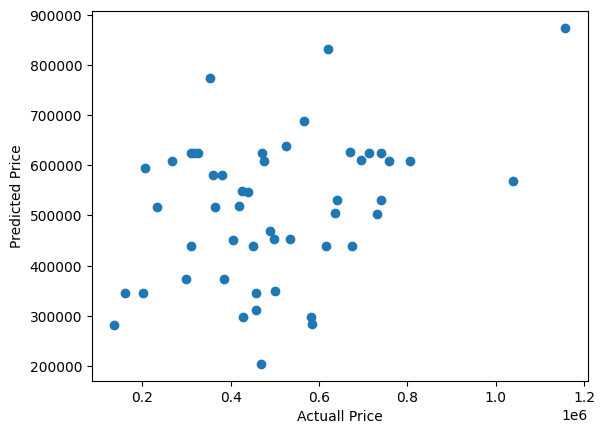

<Figure size 10x10 with 0 Axes>

In [32]:
plt.scatter(y_train[:50],predict[:50])
plt.xlabel("Actuall Price")
plt.ylabel("Predicted Price")
plt.figure(figsize=(10,10),dpi=1)

#### Now test the model to predict for unseen data
I would like to purchase a house that contains 1 floor, 3 bedrooms, 1 bathroom, 4 view, with 1 condition

So I would have to input these values to the model and model would tell me how much would it cost for me to purchase such a house

In [ ]:
Price = model.predict([[4.0,3.0,1.0,1.0,1.0]])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print(f"Price for the house is {np.ceil(Price[0][0])}")

Price for the house is 768294.0


#### Let's check the score of the prediction

In [ ]:
model.score(X_train,y_train)*100

38.323316424737854

In [ ]:
model.score(X_test,y_test)*100

39.45406188480206

In [ ]:
model.score(X_train,predict)*100

100.0